<a href="https://colab.research.google.com/github/patrickpais/CP2-SERS-PRONTO/blob/main/CP2_SERS_PRONTO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Avaliação — APIs de energia renovável e aprendizado de máquina

Consulte duas APIs públicas, organize os dados e resolva **duas tarefas**: classificar a fonte de empreendimentos da ANEEL e estimar a radiação solar em Petrolina (PE). Em **cada tarefa**, treine e compare **três algoritmos diferentes**. Este notebook fornece a consulta às APIs e os arquivos de dados; **você implementará a análise e os modelos**.

**Entrega:** um único link para um repositório público no GitHub com notebook executável, arquivos de dados, README e resultados. As instruções completas estão ao final e no enunciado separado.

## O que é recebido da API?

Uma requisição HTTP `GET` pede dados a uma URL. Os parâmetros identificam o recurso, o período e as variáveis. A resposta é **JSON**: um objeto com chaves e valores. Nas duas consultas desta avaliação, o acesso público **não exige login, token ou chave de API**. Se outra API exigir credenciais, não as publique no repositório.

Este código usa somente `json`, `urllib` e `csv`, bibliotecas que vêm com Python. `csv` serve apenas para exportar os dados recebidos; os imports para análise, tabelas, gráficos e ML são parte da sua implementação.

In [1]:
%pip install -q pandas matplotlib seaborn scikit-learn


In [2]:
import json
import urllib.parse
import urllib.request
import csv


A função a seguir monta a URL, abre a conexão, verifica o status HTTP e converte o JSON. Se houver falha na rede ou na API, exibe uma mensagem de erro.

In [3]:
def consultar_api(endereco, parametros):
    url = endereco + "?" + urllib.parse.urlencode(parametros)
    try:
        with urllib.request.urlopen(url, timeout=30) as resposta:
            return json.load(resposta)
    except Exception as erro:
        raise RuntimeError(f"Não foi possível consultar a API: {erro}") from erro

# Tarefa 1 — Classificação (ANEEL)

**Pergunta:** a partir da potência e da localização de um empreendimento, é possível classificar sua fonte como **Solar, Eólica ou Hidráulica**?

A fonte é uma **categoria**: o problema é de classificação. O conjunto [SIGA da ANEEL](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel) registra empreendimentos em várias fases. Usamos `UFV` (solar fotovoltaica), `EOL` (eólica) e três categorias hidráulicas: `UHE`, `PCH`, `CGH`. Estas três últimas formarão uma única classe, *Hidráulica*. A tarefa trata da **categoria do cadastro**, não da quantidade de energia gerada.

### Atributos originais da resposta

| Campo da API | Significado | Uso na tarefa |
|---|---|---|
| `SigTipoGeracao` | Sigla do tipo de geração (`UFV`, `EOL`, `UHE`, `PCH`, `CGH`) | Origina o alvo `fonte`; **não entra em X** |
| `MdaPotenciaOutorgadaKw` | Potência outorgada do empreendimento, em quilowatts (kW) | Entrada `potencia_kw`; potência nominal autorizada, não energia produzida |
| `NumCoordNEmpreendimento` | Latitude aproximada do empreendimento, em graus decimais | Entrada `latitude` |
| `NumCoordEEmpreendimento` | Longitude aproximada do empreendimento, em graus decimais | Entrada `longitude` |
| `CodCEG`, `NomEmpreendimento` e campos de combustível | Código, nome e descrição associados ao empreendimento e à fonte | **Não usar como entradas**: podem revelar a classe |

A resposta CKAN contém `success` e `result`; dentro de `result`, `records` são as linhas, `fields` descrevem as colunas e `total` indica o total encontrado para o filtro. O CSV final terá **três atributos numéricos e a classe**. Quantidades consultadas têm limite por tipo e não representam a participação de cada fonte na matriz brasileira.

### 1. Consultar a ANEEL

O recurso SIGA é acessado pela API pública CKAN/DataStore. `resource_id` aponta para o conjunto; `filters` seleciona uma sigla; `limit` limita o retorno de cada pedido. Não há etapa de autenticação para esta consulta pública.

In [4]:
URL_ANEEL = "https://dadosabertos.aneel.gov.br/api/3/action/datastore_search"
ID_RECURSO = "11ec447d-698d-4ab8-977f-b424d5deee6a"
SIGLAS = ["UFV", "EOL", "UHE", "PCH", "CGH"]
print("API ANEEL: consulta pública, sem token")

API ANEEL: consulta pública, sem token


In [5]:
registros_aneel = []
for sigla in SIGLAS:
    parametros = {
        "resource_id": ID_RECURSO,
        "filters": json.dumps({"SigTipoGeracao": sigla}),
        "limit": 1200,
    }
    resposta = consultar_api(URL_ANEEL, parametros)
    if not resposta.get("success"):
        raise ValueError(f"Consulta da ANEEL falhou para {sigla}")
    linhas = resposta["result"]["records"]
    print(f"{sigla}: {len(linhas)} linhas recebidas")
    registros_aneel.extend(linhas)
print("Total de linhas recebidas:", len(registros_aneel))

UFV: 1200 linhas recebidas
EOL: 1200 linhas recebidas
UHE: 221 linhas recebidas
PCH: 537 linhas recebidas
CGH: 718 linhas recebidas
Total de linhas recebidas: 3876


### 2. Gerar o CSV para a tarefa

A API pode fornecer números como texto, inclusive com vírgula decimal. O tratamento abaixo converte esses valores, descarta linhas sem potência ou coordenadas e transforma as siglas em três classes. Cada linha do arquivo final representa **um empreendimento**. Confira a quantidade de exemplos por classe durante sua análise; se necessário, discuta o desequilíbrio entre classes.

In [6]:
def numero(valor):
    texto = str(valor).strip()
    if "," in texto:
        texto = texto.replace(".", "").replace(",", ".")
    try:
        return float(texto)
    except ValueError:
        return None

fontes = {"UFV": "Solar", "EOL": "Eólica", "UHE": "Hidráulica",
          "PCH": "Hidráulica", "CGH": "Hidráulica"}
linhas_classificacao = []
for registro in registros_aneel:
    potencia = numero(registro.get("MdaPotenciaOutorgadaKw"))
    latitude = numero(registro.get("NumCoordNEmpreendimento"))
    longitude = numero(registro.get("NumCoordEEmpreendimento"))
    fonte = fontes.get(registro.get("SigTipoGeracao"))
    if fonte and all(valor is not None for valor in (potencia, latitude, longitude)):
        linhas_classificacao.append([potencia, latitude, longitude, fonte])
if len(linhas_classificacao) < 90:
    raise ValueError("Poucos registros válidos: confira a resposta da ANEEL")
print("Linhas válidas:", len(linhas_classificacao))
print("Primeiro exemplo:", linhas_classificacao[0])

Linhas válidas: 3876
Primeiro exemplo: [20.48, -10.44277778, -64.15194444, 'Solar']


In [7]:
with open("aneel_classificacao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["potencia_kw", "latitude", "longitude", "fonte"])
    escritor.writerows(linhas_classificacao)
print("Salvo: aneel_classificacao_orange.csv")

Salvo: aneel_classificacao_orange.csv


### O que você deve fazer — classificação

1. Carregue o CSV, confira os tipos das colunas, as contagens por classe, valores ausentes e distribuições relevantes. Explique `X` (três entradas) e `y` (`fonte`).
2. Faça uma divisão **estratificada** de treino/teste, por exemplo 80%/20%, com semente fixa. Ajustes de escala aprendidos dos dados devem ser feitos **somente com o treino**.
3. Escolha, justifique e treine **três classificadores diferentes** usando a mesma divisão. Eles **não estão importados nem implementados** neste notebook.
4. Compare Accuracy, Precision, Recall e F1. Declare o tipo de média usado nas métricas por classe (por exemplo, `macro`) e apresente a matriz de confusão.
5. Explique qual modelo escolheria, quais classes ele mais confunde e por que potência/localização podem não bastar para uma aplicação real. Não use `SigTipoGeracao`, nomes, CEG ou descrições da fonte como entradas.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico(s) ou matriz de confusão e interpretação escrita.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_aneel = pd.read_csv("aneel_classificacao_orange.csv")

print(df_aneel.shape)
df_aneel.info()

(3876, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3876 entries, 0 to 3875
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   potencia_kw  3876 non-null   float64
 1   latitude     3876 non-null   float64
 2   longitude    3876 non-null   float64
 3   fonte        3876 non-null   object 
dtypes: float64(3), object(1)
memory usage: 121.3+ KB


In [9]:
print(df_aneel["fonte"].value_counts())
print()
print(df_aneel["fonte"].value_counts(normalize=True).round(3))

fonte
Hidráulica    1476
Solar         1200
Eólica        1200
Name: count, dtype: int64

fonte
Hidráulica    0.381
Solar         0.310
Eólica        0.310
Name: proportion, dtype: float64


In [10]:
df_aneel.groupby("fonte")[["potencia_kw", "latitude", "longitude"]].describe().T

fonte                     Eólica    Hidráulica          Solar
potencia_kw count    1200.000000  1.476000e+03    1200.000000
            mean    30782.769883  7.580916e+04   11679.386733
            std     13800.597800  4.864196e+05   18374.855154
            min         0.160000  9.900000e-01       0.260000
            25%     23100.000000  9.900000e+02       1.000000
            50%     29600.000000  4.000000e+03       1.000000
            75%     37200.000000  1.700000e+04   28880.000000
            max    105000.000000  1.123310e+07  137480.000000
latitude    count    1200.000000  1.476000e+03    1200.000000
            mean       -9.896436 -2.111301e+01      -5.136029
            std         7.529853  6.500423e+00       5.546914
            min       -33.722806 -3.078799e+01     -29.835550
            25%       -11.136206 -2.675362e+01      -6.924585
            50%        -7.986274 -2.203073e+01      -2.055540
            75%        -5.271434 -1.760462e+01      -1.831473
            max         0.000000  3.801667e+00       3.831392
longitude   count    1200.000000  1.476000e+03    1200.000000
            mean      -39.715921 -4.893246e+01     -49.188463
            std         7.231867  7.976908e+00       5.912291
            min       -55.930850 -6.464614e+01     -69.941389
            25%       -41.865407 -5.263224e+01     -53.067800
            50%       -40.692088 -5.041888e+01     -52.440865
            75%       -36.491659 -4.619944e+01     -44.881156
            max         0.000000  0.000000e+00     -35.235400

In [11]:
print("Linhas duplicadas:", df_aneel.duplicated().sum())
print(df_aneel[df_aneel.duplicated(keep=False)]["fonte"].value_counts())
print()
print(df_aneel[df_aneel["fonte"] == "Solar"].value_counts().head(5))
print()
print("Coordenadas zeradas:", ((df_aneel["latitude"] == 0) | (df_aneel["longitude"] == 0)).sum())


Linhas duplicadas: 28
fonte
Eólica        20
Hidráulica    16
Solar          8
Name: count, dtype: int64

potencia_kw  latitude    longitude   fonte
30000.0      -9.531903   -40.487846  Solar    4
             -4.099503   -41.483294  Solar    2
27000.0      -13.322731  -43.295141  Solar    2
16.2         -1.682500   -61.824167  Solar    1
930.0        -27.577900  -48.508170  Solar    1
Name: count, dtype: int64

Coordenadas zeradas: 47


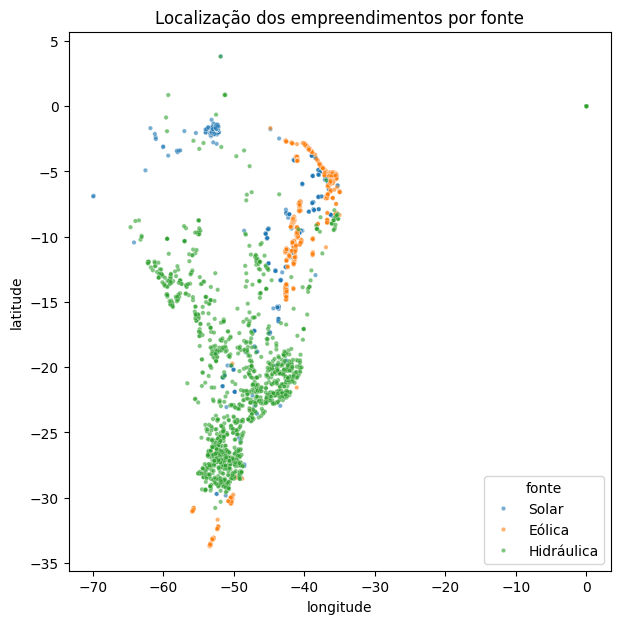

In [12]:
plt.figure(figsize=(7, 7))
sns.scatterplot(data=df_aneel, x="longitude", y="latitude", hue="fonte", s=10, alpha=0.6)
plt.title("Localização dos empreendimentos por fonte")
plt.show()


### Exploração dos dados — ANEEL

- O conjunto tem **3876 empreendimentos** e 4 colunas, sem valores ausentes.
- **X (entradas):** `potencia_kw`, `latitude` e `longitude`, todas numéricas (float).
- **y (alvo):** `fonte`, categórica com 3 classes: Hidráulica (38%), Solar (31%) e Eólica (31%).
- Solar e Eólica atingiram o limite de 1200 registros por consulta, então as proporções
  refletem a amostragem, não a participação de cada fonte na matriz brasileira.
- **Potência (describe):** as classes têm perfis bem diferentes. Eólica é a mais homogênea
  (mediana ≈ 29.600 kW, 50% central entre 23.100 e 37.200 kW). Hidráulica tem a maior
  assimetria: mediana de 4.000 kW, mas média de ≈ 75.800 kW e máximo de 11.233.100 kW
  (porte de Belo Monte), porque a classe junta CGH pequenas, PCH e UHE gigantes. Solar tem
  mediana de **1 kW** (25% e 50% iguais a 1,0), o que indica valor padrão de cadastro em
  metade das linhas, e não potência real. Em todas as classes a média fica bem acima da
  mediana, sinal de distribuição assimétrica; isso favorece modelos baseados em árvore e
  vizinhança e prejudica um modelo linear, mesmo com padronização.
- **Mapa:** Hidráulica se concentra no Sul, Sudeste e Centro-Oeste; Eólica forma uma faixa
  no litoral e interior do Nordeste (RN, CE, BA) e um núcleo no Rio Grande do Sul; Solar
  aparece espalhada, com um aglomerado muito denso em torno de latitude −2 / longitude −52
  (Pará), om dezenas de registros de 1 kW e coordenadas quase idênticas, provavelmente unidades de um mesmo complexo. Solar e Eólica se misturam
  no interior do Nordeste; Solar e Hidráulica se misturam em Minas Gerais e no Sul. Há 47 registros em (0, 0), coordenada não preenchida (1,2% do total), e apenas 28 linhas duplicadas exatas (0,7%).


In [13]:
from sklearn.model_selection import train_test_split

X = df_aneel[["potencia_kw", "latitude", "longitude"]]
y = df_aneel["fonte"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Treino:", X_train.shape, " Teste:", X_test.shape)
print(y_train.value_counts(normalize=True).round(3))
print(y_test.value_counts(normalize=True).round(3))

Treino: (3100, 3)  Teste: (776, 3)
fonte
Hidráulica    0.381
Solar         0.310
Eólica        0.310
Name: proportion, dtype: float64
fonte
Hidráulica    0.381
Solar         0.309
Eólica        0.309
Name: proportion, dtype: float64


### Escolha dos classificadores

Os três algoritmos foram escolhidos por funcionarem de maneiras diferentes, o que torna a comparação informativa:

- **Regressão Logística:** modelo linear e interpretável; serve de referência e testa se
  fronteiras retas bastam para separar as classes. Exige padronização, porque `potencia_kw`
  (até milhões de kW) domina a escala de latitude e longitude (dezenas de graus).
- **KNN (k=5):** classifica pela vizinhança dos 5 exemplos mais próximos; faz sentido porque
  usinas próximas no mapa tendem a ser do mesmo tipo. Depende de distância, então também
  exige padronização.
- **Random Forest (200 árvores):** conjunto de árvores de decisão que captura relações não
  lineares entre potência e localização (regiões irregulares no mapa). Árvores comparam
  limiares de uma variável por vez, então não precisam de padronização.

A padronização é feita dentro de um `Pipeline` do scikit-learn: o `StandardScaler` aprende
média e desvio **apenas com o treino** e só aplica esses valores ao teste, evitando vazamento.


In [14]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

modelos = {
    "Regressão Logística": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "KNN (k=5)": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
}

resultados = []
previsoes = {}

for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    previsoes[nome] = y_pred
    resultados.append({
        "Modelo": nome,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (macro)": precision_score(y_test, y_pred, average="macro"),
        "Recall (macro)": recall_score(y_test, y_pred, average="macro"),
        "F1 (macro)": f1_score(y_test, y_pred, average="macro"),
    })

tabela_clf = pd.DataFrame(resultados).set_index("Modelo").round(3)
tabela_clf

,Accuracy,Precision (macro),Recall (macro),F1 (macro)
Modelo,,,,
Regressão Logística,0.825,0.828,0.821,0.820
KNN (k=5),0.965,0.966,0.964,0.965
Random Forest,0.976,0.977,0.974,0.975


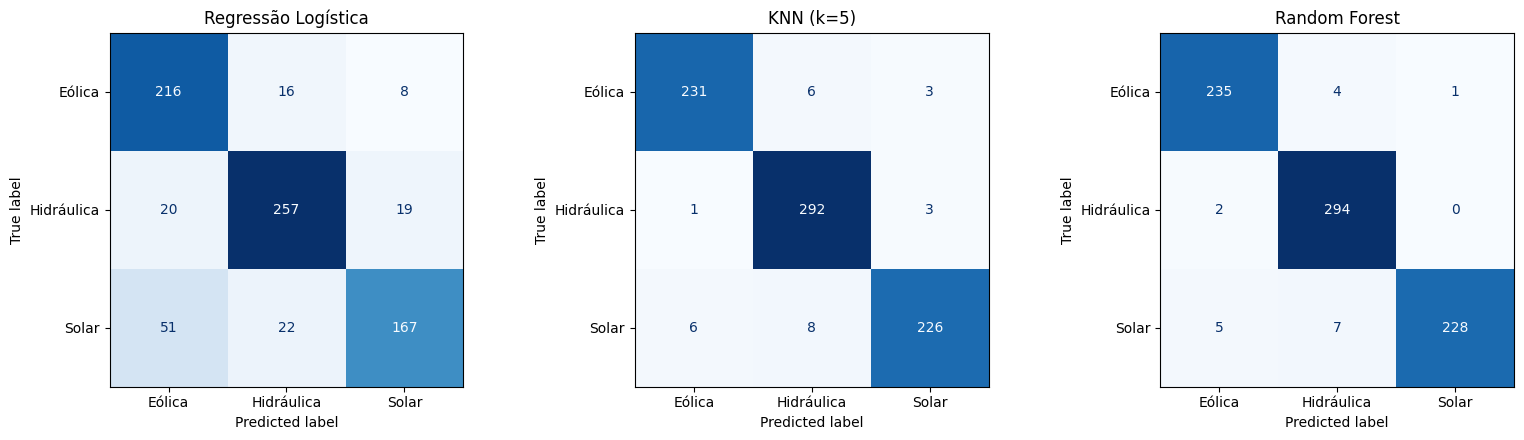

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, eixos = plt.subplots(1, 3, figsize=(16, 4.5))

for eixo, (nome, y_pred) in zip(eixos, previsoes.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, ax=eixo, cmap="Blues", colorbar=False
    )
    eixo.set_title(nome)

plt.tight_layout()
plt.show()

### Comparação e conclusões — Classificação

**Configuração:** divisão estratificada 80/20 (`random_state=42`); padronização via
`Pipeline` ajustada apenas no treino (Regressão Logística e KNN); métricas por classe
com média **macro** (mesmo peso para as três classes).

| Modelo | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|
| Regressão Logística | 0,825 | 0,828 | 0,821 | 0,820 |
| KNN (k=5) | 0,965 | 0,966 | 0,964 | 0,965 |
| Random Forest | 0,976 | 0,977 | 0,974 | 0,975 |

**Modelo escolhido:** Random Forest — maior F1 macro e menos erros (19 de 776).

**Classes mais confundidas:** Solar é a classe com mais erros nos três modelos,
sobretudo confundida com Eólica na Regressão Logística (51 casos). Solar e eólica
coexistem no semiárido nordestino, então a localização sozinha não as separa.
Fronteiras lineares não capturam esses agrupamentos geográficos; KNN e Random
Forest capturam.

**Limitações:**
- Potência e localização não descrevem o recurso físico (irradiação, vento, vazão
  de rios), que é o que de fato define a fonte de uma usina.
- Usinas do mesmo complexo têm coordenadas e potências quase iguais; a divisão
  aleatória coloca "irmãs" no treino e no teste, o que tende a inflar o desempenho.
  Em uma região nova, o resultado provavelmente seria pior.
- A amostra foi limitada a 1200 registros por sigla; as proporções não representam
  a matriz energética brasileira.
- O cadastro inclui empreendimentos em diferentes fases (não só usinas em operação).
- A verificação mostrou apenas 28 duplicatas exatas, então o efeito vem de vizinhança real, não de linhas repetidas.

# Tarefa 2 — Regressão (Open-Meteo)

**Pergunta:** dadas as condições meteorológicas e a hora local em Petrolina (PE), qual é a radiação solar horizontal média naquela hora? A resposta é um **número**, então o problema é de regressão.

A API histórica do [Open-Meteo](https://open-meteo.com/en/docs/historical-weather-api) devolve dados horários para coordenadas e período escolhidos. Usamos **1º de abril a 30 de junho de 2025**, em horário local. São dados históricos estimados por modelos/reanálise, não leituras de um sensor particular. **Radiação em W/m² não equivale à energia em kWh nem à geração de um painel.**

### Parâmetros da requisição

| Parâmetro | Valor nesta avaliação | Significado |
|---|---|---|
| `latitude`, `longitude` | `-9.39`, `-40.50` | Coordenadas aproximadas de Petrolina (PE) |
| `start_date`, `end_date` | `2025-04-01`, `2025-06-30` | Período histórico consultado, inclusive as datas extremas |
| `timezone` | `America/Recife` | Faz `time` representar a hora local |
| `hourly` | Lista das cinco variáveis abaixo | Solicita valores horários em JSON |

### Atributos do conjunto de dados

| Campo da API → CSV | Significado e unidade | Uso na tarefa |
|---|---|---|
| `time` → `data_hora` | Data e hora local de cada registro | Ordenar e separar por tempo; não é entrada em X |
| `temperature_2m` → `temperatura_c` | Temperatura do ar a 2 m, em °C | Entrada |
| `relative_humidity_2m` → `umidade_pct` | Umidade relativa a 2 m, em % | Entrada |
| `cloud_cover` → `nuvens_pct` | Cobertura total de nuvens, em % | Entrada |
| `wind_speed_10m` → `vento_kmh` | Velocidade do vento a 10 m, em km/h | Entrada |
| `time` → `hora` | Hora local extraída da data, de 7 a 17 nesta amostra | Entrada |
| `shortwave_radiation` → `radiacao_w_m2` | Radiação solar global horizontal média da hora anterior, em W/m² | Alvo numérico `y`; **não entra em X** |

A resposta inclui `hourly` (listas dos valores, alinhadas por índice), `hourly_units` (unidades) e metadados da localização. Cada linha do CSV final representa **uma hora entre 7h e 17h**; esse recorte reduz o domínio de horas noturnas, mas não remove a importância da hora para a previsão.

### 3. Consultar o histórico meteorológico

A chamada usa GET, sem cadastro ou chave para esta consulta pública de uso educacional. Se `hourly` faltar, verifique datas e parâmetros.

In [16]:
URL_METEO = "https://archive-api.open-meteo.com/v1/archive"
parametros_meteo = {
    "latitude": -9.39,
    "longitude": -40.50,
    "start_date": "2025-04-01",
    "end_date": "2025-06-30",
    "timezone": "America/Recife",
    "hourly": ",".join(["temperature_2m", "relative_humidity_2m",
                         "cloud_cover", "wind_speed_10m", "shortwave_radiation"]),
}
print("Open-Meteo: consulta pública, sem token")

Open-Meteo: consulta pública, sem token


In [17]:
resposta_meteo = consultar_api(URL_METEO, parametros_meteo)
if "hourly" not in resposta_meteo:
    raise ValueError("Resposta sem a seção hourly")
horas_api = resposta_meteo["hourly"]
print("Campos recebidos:", list(horas_api))
print("Unidades informadas pela API:", resposta_meteo.get("hourly_units", {}))
print("Quantidade de horários:", len(horas_api["time"]))

Campos recebidos: ['time', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation']
Unidades informadas pela API: {'time': 'iso8601', 'temperature_2m': '°C', 'relative_humidity_2m': '%', 'cloud_cover': '%', 'wind_speed_10m': 'km/h', 'shortwave_radiation': 'W/m²'}
Quantidade de horários: 2184


### 4. Gerar o CSV horário

As listas de `hourly` são alinhadas: o índice 0 de cada variável se refere ao índice 0 de `time`. Percorremos esses índices, mantemos as horas de 7h a 17h e descartamos linhas com valores ausentes. A data permanece ordenada para facilitar uma avaliação temporal.

In [18]:
nomes_api = ["temperature_2m", "relative_humidity_2m", "cloud_cover",
             "wind_speed_10m", "shortwave_radiation"]
linhas_regressao = []
for indice, data_hora in enumerate(horas_api["time"]):
    hora = int(data_hora[11:13])
    valores = [horas_api[nome][indice] for nome in nomes_api]
    if 7 <= hora <= 17 and all(valor is not None for valor in valores):
        linhas_regressao.append([data_hora, *valores[:4], hora, valores[4]])
if len(linhas_regressao) < 100:
    raise ValueError("Poucos horários válidos: confira a resposta do Open-Meteo")
print("Horas válidas:", len(linhas_regressao))
print("Primeiro exemplo:", linhas_regressao[0])

Horas válidas: 1001
Primeiro exemplo: ['2025-04-01T07:00', 25.3, 74, 100, 17.7, 7, 116.0]


In [19]:
with open("meteo_regressao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["data_hora", "temperatura_c", "umidade_pct",
                       "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"])
    escritor.writerows(linhas_regressao)
print("Salvo: meteo_regressao_orange.csv")

Salvo: meteo_regressao_orange.csv


### O que você deve fazer — regressão

1. Carregue o CSV, explique as colunas, examine valores ausentes e apresente ao menos uma visualização. Defina `X` (cinco entradas) e `y` (`radiacao_w_m2`).
2. Mantenha as linhas em ordem de `data_hora`: use aproximadamente **80% das primeiras horas para treino** e as 20% finais para teste. Evite embaralhar as horas. Ajuste transformações apenas com o treino.
3. Escolha, justifique e treine **três algoritmos de regressão diferentes** com a mesma divisão. Os imports e a implementação são sua responsabilidade.
4. Compare **MAE** (W/m²), **MSE** ((W/m²)²) e **R²**; faça um gráfico de valores reais × previstos de pelo menos um modelo.
5. Interprete os erros, discuta o peso da hora e explique por que essa estimativa da radiação **não prevê automaticamente a energia produzida** por um sistema fotovoltaico.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico e interpretação escrita. Nenhum valor de `radiacao_w_m2` deve ser usado para criar uma entrada do mesmo registro.

In [20]:
df_meteo = pd.read_csv("meteo_regressao_orange.csv", parse_dates=["data_hora"])

print(df_meteo.shape)
df_meteo.info()
df_meteo.describe().round(1)

(1001, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   data_hora      1001 non-null   datetime64[ns]
 1   temperatura_c  1001 non-null   float64       
 2   umidade_pct    1001 non-null   int64         
 3   nuvens_pct     1001 non-null   int64         
 4   vento_kmh      1001 non-null   float64       
 5   hora           1001 non-null   int64         
 6   radiacao_w_m2  1001 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(3)
memory usage: 54.9 KB


,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
count,1001,1001.0,1001.0,1001.0,1001.0,1001.0,1001.0
mean,2025-05-16 11:59:59.999999744,28.9,50.5,55.1,15.5,12.0,472.9
min,2025-04-01 07:00:00,19.5,21.0,0.0,2.3,7.0,13.0
25%,2025-04-23 15:00:00,26.3,38.0,19.0,12.2,9.0,250.0
50%,2025-05-16 12:00:00,29.1,49.0,54.0,15.4,12.0,466.0
75%,2025-06-08 09:00:00,31.7,61.0,98.0,19.0,15.0,696.0
max,2025-06-30 17:00:00,36.1,95.0,100.0,30.1,17.0,1002.0
std,NaN,3.7,15.9,37.9,4.9,3.2,256.4


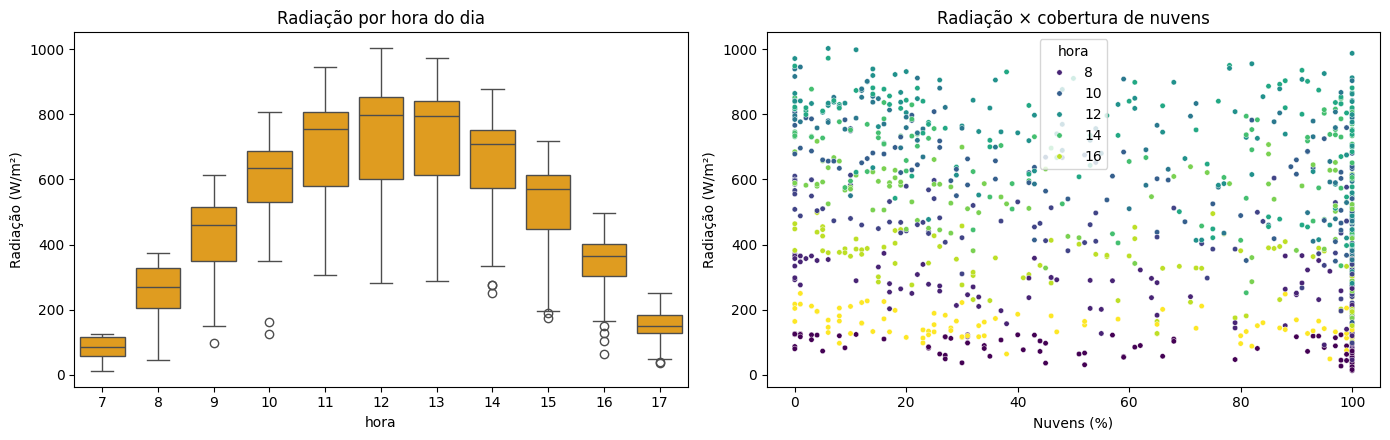

In [21]:
fig, eixos = plt.subplots(1, 2, figsize=(14, 4.5))

sns.boxplot(data=df_meteo, x="hora", y="radiacao_w_m2", ax=eixos[0], color="orange")
eixos[0].set_title("Radiação por hora do dia")
eixos[0].set_ylabel("Radiação (W/m²)")

sns.scatterplot(data=df_meteo, x="nuvens_pct", y="radiacao_w_m2", hue="hora",
                palette="viridis", s=15, ax=eixos[1])
eixos[1].set_title("Radiação × cobertura de nuvens")
eixos[1].set_xlabel("Nuvens (%)")
eixos[1].set_ylabel("Radiação (W/m²)")

plt.tight_layout()
plt.show()

### Exploração dos dados — Open-Meteo

- O conjunto tem **1001 horas** (91 dias × 11 horas, das 7h às 17h) de 01/04 a 30/06/2025
  em Petrolina (PE), sem valores ausentes. `data_hora` já foi lida como data
  (`datetime64`) e será usada apenas para ordenar e dividir os dados, não como entrada.
- **X (entradas):** `temperatura_c`, `umidade_pct`, `nuvens_pct`, `vento_kmh` e `hora`.
- **y (alvo):** `radiacao_w_m2`, radiação solar global horizontal média da hora anterior,
  que varia de 13 a 1002 W/m² (média ≈ 473, desvio ≈ 256).
- **Radiação por hora (boxplot):** a curva tem formato de sino. Às 7h a mediana fica em
  torno de 90 W/m²; sobe até o pico entre **12h e 13h (≈ 800 W/m²)** e cai para ≈ 160 W/m²
  às 17h. A hora do dia define o *teto* de radiação possível, porque reflete a altura do
  sol no céu. As caixas são mais largas entre 11h e 14h: é no meio do dia que as
  condições meteorológicas mais alteram o resultado.
- **Radiação × nuvens (dispersão):** a cor dos pontos (hora) explica a maior parte da
  posição vertical: as manhãs cedo e os fins de tarde ficam na base do gráfico e o
  meio-dia no topo, em qualquer nível de nuvens. A cobertura de nuvens reduz a radiação,
  mas de forma menos clara que o esperado: mesmo com 100% de cobertura há horas acima de
  800 W/m². A `nuvens_pct` é a cobertura *total* e não distingue nuvens finas e altas de
  nuvens espessas, o que explica parte desse ruído.
- **Expectativa para os modelos:** a relação entre `hora` e radiação é curva (sobe e desce),
  não uma reta. Um modelo linear tende a ter dificuldade com isso; modelos de árvore e de
  vizinhança devem capturar melhor o formato de sino.

In [22]:
df_meteo = df_meteo.sort_values("data_hora").reset_index(drop=True)

colunas_X = ["temperatura_c", "umidade_pct", "nuvens_pct", "vento_kmh", "hora"]
X_m = df_meteo[colunas_X]
y_m = df_meteo["radiacao_w_m2"]

corte = int(len(df_meteo) * 0.8)
X_train_m, X_test_m = X_m.iloc[:corte], X_m.iloc[corte:]
y_train_m, y_test_m = y_m.iloc[:corte], y_m.iloc[corte:]

print("Treino:", X_train_m.shape, "de", df_meteo["data_hora"].iloc[0], "até", df_meteo["data_hora"].iloc[corte - 1])
print("Teste: ", X_test_m.shape, "de", df_meteo["data_hora"].iloc[corte], "até", df_meteo["data_hora"].iloc[-1])

Treino: (800, 5) de 2025-04-01 07:00:00 até 2025-06-12 14:00:00
Teste:  (201, 5) de 2025-06-12 15:00:00 até 2025-06-30 17:00:00


In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

regressores = {
    "Regressão Linear": make_pipeline(StandardScaler(), LinearRegression()),
    "KNN (k=5)": make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=5)),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
}

resultados_reg = []
previsoes_reg = {}

for nome, modelo in regressores.items():
    modelo.fit(X_train_m, y_train_m)
    y_pred = modelo.predict(X_test_m)
    previsoes_reg[nome] = y_pred
    resultados_reg.append({
        "Modelo": nome,
        "MAE (W/m²)": mean_absolute_error(y_test_m, y_pred),
        "MSE ((W/m²)²)": mean_squared_error(y_test_m, y_pred),
        "R²": r2_score(y_test_m, y_pred),
    })

tabela_reg = pd.DataFrame(resultados_reg).set_index("Modelo").round(3)
tabela_reg

,MAE (W/m²),MSE ((W/m²)²),R²
Modelo,,,
Regressão Linear,145.205,30034.201,0.360
KNN (k=5),68.271,7607.961,0.838
Random Forest,66.252,7250.888,0.845


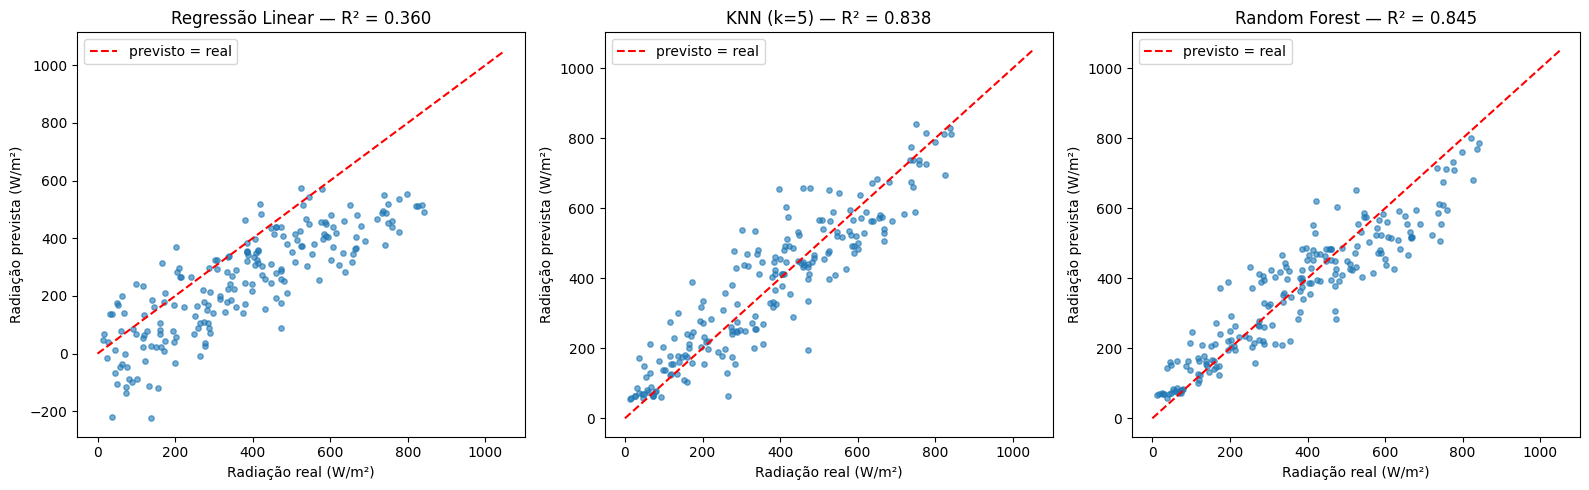

In [24]:
fig, eixos = plt.subplots(1, 3, figsize=(16, 5))

for eixo, (nome, y_pred) in zip(eixos, previsoes_reg.items()):
    eixo.scatter(y_test_m, y_pred, s=15, alpha=0.6)
    eixo.plot([0, 1050], [0, 1050], "r--", label="previsto = real")
    eixo.set_xlabel("Radiação real (W/m²)")
    eixo.set_ylabel("Radiação prevista (W/m²)")
    eixo.set_title(f"{nome} — R² = {r2_score(y_test_m, y_pred):.3f}")
    eixo.legend()

plt.tight_layout()
plt.show()

In [25]:
importancias = pd.Series(
    regressores["Random Forest"].feature_importances_, index=colunas_X
).sort_values(ascending=False)
print(importancias.round(3))

hora             0.488
temperatura_c    0.295
umidade_pct      0.179
nuvens_pct       0.022
vento_kmh        0.016
dtype: float64


### Comparação e conclusões — Regressão

**Configuração:** divisão temporal sem embaralhar, primeiras 800 horas (01/04 a 12/06)
para treino e últimas 201 (12/06 a 30/06) para teste; padronização via `Pipeline`
ajustada apenas no treino (Regressão Linear e KNN); mesmas entradas e mesma divisão
para os três modelos.

| Modelo | MAE (W/m²) | MSE ((W/m²)²) | R² |
|---|---|---|---|
| Regressão Linear | 145,2 | 30.034 | 0,360 |
| KNN (k=5) | 68,3 | 7.608 | 0,838 |
| Random Forest | 66,3 | 7.251 | 0,845 |

**Modelo escolhido:** Random Forest — menor MAE e MSE e maior R²; no gráfico real ×
previsto é o mais concentrado em torno da diagonal e não gera valores negativos.

**Interpretação dos erros:** a Regressão Linear prevê radiação negativa nas horas de
sol baixo e satura em ≈ 500 W/m² nas horas de pico, porque uma reta não representa a
curva em forma de sino da radiação ao longo do dia. KNN e Random Forest capturam essa
curva, mas ainda subestimam as horas de céu limpo ao meio-dia (700–850 W/m²), onde a
variabilidade é maior. O erro médio de ≈ 66 W/m² corresponde a ≈ 14% da radiação média.

**Papel da hora:** é a variável mais importante no Random Forest (0,49), porque define o
teto físico de radiação (altura do sol). Temperatura (0,30) e umidade (0,18) vêm em
seguida, mas em parte são consequência da radiação, e não causa: ajudam a prever, não a
explicar. A cobertura de nuvens teve peso quase nulo (0,02), o que é consistente com a
dispersão: `nuvens_pct` é a cobertura total e não distingue nuvens finas de espessas.

**Radiação não é geração elétrica:** a radiação em W/m² é a energia solar que chega ao
plano horizontal. A energia que um sistema fotovoltaico entrega depende ainda da área e
da inclinação dos

# Entrega pelo GitHub

Envie **apenas o link do repositório público**. Organize-o com:

- `README.md` contendo objetivo, fontes e período dos dados, instruções para executar o notebook e resumo dos resultados;
- notebook `.ipynb` com a consulta às APIs, sua análise, os **três classificadores e os três regressores**, todos os imports necessários adicionados por você e conclusões em Markdown;
- os dois CSVs gerados (ou instruções completas e testadas para reproduzi-los) e eventuais figuras utilizadas.

Verifique se o notebook roda **na ordem das células** a partir de um ambiente limpo. Não inclua senhas, tokens ou arquivos sem relação com a avaliação. A banca deve conseguir encontrar as seis comparações e as respostas às duas tarefas sem procurar uma agulha no palheiro.

### Fontes

- [ANEEL — SIGA](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel)
- [ANEEL — recurso e campos usados](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel/resource/11ec447d-698d-4ab8-977f-b424d5deee6a)
- [Open-Meteo — histórico e unidades](https://open-meteo.com/en/docs/historical-weather-api)